In [1]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


Preprocess our data

In [2]:
data_train = pd.read_csv('datasets/emotions_data/emotion-labels-train.csv')
data_test  = pd.read_csv('datasets/emotions_data/emotion-labels-test.csv')
data_val   = pd.read_csv('datasets/emotions_data/emotion-labels-val.csv')

In [3]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [4]:
data = pd.concat([data_train, data_test, data_val], ignore_index = True)

In [5]:
data['text_clean'] = data['text'].apply(lambda x : clean(x, no_emoji = True))

In [6]:
data['text_clean'] = data['text_clean'].apply(lambda x : re.sub('@[^\s]+', "", x))

In [7]:
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game #cheer #fr...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": thank you so much, gloria! you're so sweet,..."
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"today i reached 1000 subscribers on yt!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,"good morning, love! happy first day of fall. ..."
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#bridgetjonesbaby is the best thing i've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
9,@IndyMN I thought the holidays could not get a...,joy,i thought the holidays could not get any more...


<Axes: xlabel='label'>

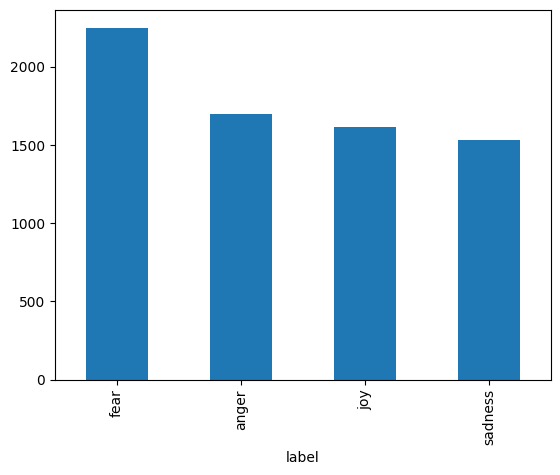

In [8]:
data['label'].value_counts().plot(kind = "bar")

In [9]:
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x : x.sample(g.size().min()).reset_index(drop=True)))
data

text    label   
label                                                                      
anger   0     Be quick to #listen, slow to #speak, and slow ...    anger  \
        1     @stoozyboy1 @chris_sutton73 😂😂 Oh the zombie r...    anger   
        2     @EmmaHobbs1 I did that! 3 days later my order ...    anger   
        3                            Literally fuming fuck sake    anger   
        4     @jbanks88 offense can't score 3 redzone trips ...    anger   
...                                                         ...      ...   
sadness 1528  My son 11 has 128 friends on Facebook and yet ...  sadness   
        1529  Overwhelming sadness.  This too shall pass.  #...  sadness   
        1530  @A_RockasThe U.S. has added years to the Syria...  sadness   
        1531  Write drunk. Edit Sober. \nForget to save. Wak...  sadness   
        1532  “Optimism may sometimes be delusional, but pes...  sadness   

                                                     text_clean  
label                                                            
anger   0     be quick to #listen, slow to #speak, and slow ...  
        1                                    oh the zombie rage  
        2      i did that! 3 days later my order isn't even ...  
        3                            literally fuming fuck sake  
        4      offense can't score 3 redzone trips no points...  
...                                                         ...  
sadness 1528  my son 11 has 128 friends on facebook and yet ...  
        1529  overwhelming sadness. this too shall pass. #lo...  
        1530   u.s. has added years to the syrian conflict b...  
        1531  write drunk. edit sober.\nforget to save. wake...  
        1532  "optimism may sometimes be delusional, but pes...  

[6132 rows x 3 columns]

<Axes: xlabel='label'>

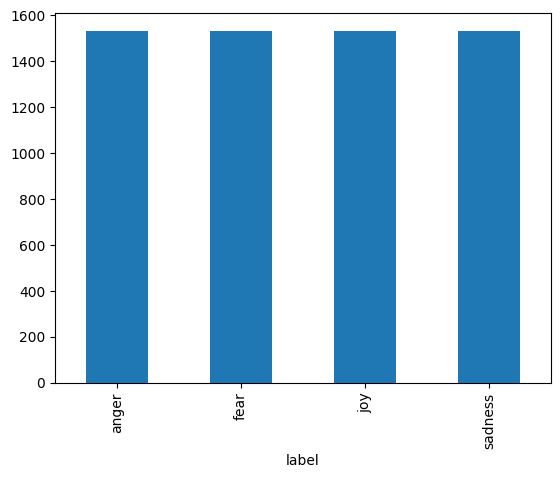

In [10]:
data['label'].value_counts().plot(kind = "bar")

In [11]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [12]:
num_labels = 4

In [13]:
train_split, test_split = train_test_split(data, train_size = 0.8)
train_split, val_split = train_test_split(train_split, train_size = 0.9)

In [14]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [15]:
train_df = pd.DataFrame({
    "label" : train_split.label_int.values,
    "text"  : train_split.text_clean.values
})

test_df = pd.DataFrame({
    "label" : test_split.label_int.values,
    "text"  : test_split.text_clean.values
})

In [16]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [17]:
dataset_dict = datasets.DatasetDict({"train":train_df, "test":test_df})
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

XLNet Embeddings

In [18]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [19]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", max_length = 128, truncation = True)

In [20]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched = True)

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [21]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [22]:
print(tokenized_datasets['train']['text'][0])

pm #sheikhhasina in  speech terms #terrorism as global challenge and urges world leaders to work together to unroot it from everywhere.


In [23]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6103, 17, 7967, 4973, 18506, 7270, 1933, 25, 2077, 1109, 17, 7967, 13489, 34, 1150, 2134, 21, 6807, 23, 185, 783, 22, 154, 511, 22, 422, 11539, 36, 40, 5937, 9, 4, 3]


In [24]:
tokenizer.decode(5)

'<pad>'

In [25]:
print(tokenized_datasets['train']['token_type_ids'][0])

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]


In [26]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [27]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

FineTuning XLNet

In [28]:
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased',
                                                      num_labels = num_labels,
                                                      id2label = {0 : 'anger', 1 : 'fear', 2 : 'joy', 3 : 'sadness'})

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
metric = evaluate.load("accuracy")

In [30]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)
    return metric.compute(predictions = predictions, references = labels)

In [31]:
training_args = TrainingArguments(output_dir = "test_trainer", eval_strategy = "epoch", num_train_epochs = 3)

In [32]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = small_train_dataset,
    eval_dataset = small_eval_dataset,
    compute_metrics = compute_metrics)

In [33]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.432308,0.330000
2,No log,1.367522,0.390000
3,No log,1.376969,0.390000


TrainOutput(global_step=39, training_loss=1.3590959402231069, metrics={'train_runtime': 474.9194, 'train_samples_per_second': 0.632, 'train_steps_per_second': 0.082, 'total_flos': 21366375321600.0, 'train_loss': 1.3590959402231069, 'epoch': 3.0})

Evaluate model

In [34]:
trainer.evaluate()

{'eval_loss': 1.3769694566726685,
 'eval_accuracy': 0.39,
 'eval_runtime': 15.1427,
 'eval_samples_per_second': 6.604,
 'eval_steps_per_second': 0.859,
 'epoch': 3.0}

In [35]:
model.save_pretrained("fine-tuned-model")

In [36]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine-tuned-model")

In [37]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer = tokenizer)

Device set to use cpu


In [38]:
rand_int = random.randint(0, len(val_split))
print(val_split['text_clean'][rand_int])
answer = clf(val_split['text_clean'][rand_int], top_k = None)
print(answer)

happy birthday to stephen king, a man responsible for some of the best horror of the past 40 years... and a whole bunch of the worst.
[{'label': 'anger', 'score': 0.3365474343299866}, {'label': 'sadness', 'score': 0.2692437469959259}, {'label': 'joy', 'score': 0.21557076275348663}, {'label': 'fear', 'score': 0.1786380410194397}]
